# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [8]:
# Diferencias entre LabelEncoder y OneHotEncoder
print('LabelEncoder:')
print('- Convierte cada categoría en un número (0, 1, 2, ...)')
print('- Genera UNA sola columna')
print('- Problema: el modelo puede pensar que hay un orden (ej: 2 > 1 > 0)')
print('- Ejemplo con sex: male=1, female=0')
print()
print('OneHotEncoder:')
print('- Crea una columna nueva por CADA categoría (0 o 1)')
print('- NO asume ningún orden entre categorías')
print('- Genera más columnas, pero es más justo para el modelo')
print('- Ejemplo con embarked: embarked_C, embarked_Q, embarked_S')
print()
print('Resumen rápido:')
print('- LabelEncoder: bueno para 2 categorías (sí/no, male/female)')
print('- OneHotEncoder: bueno para 3+ categorías (ciudades, clases, etc.)')

LabelEncoder:
- Convierte cada categoría en un número (0, 1, 2, ...)
- Genera UNA sola columna
- Problema: el modelo puede pensar que hay un orden (ej: 2 > 1 > 0)
- Ejemplo con sex: male=1, female=0

OneHotEncoder:
- Crea una columna nueva por CADA categoría (0 o 1)
- NO asume ningún orden entre categorías
- Genera más columnas, pero es más justo para el modelo
- Ejemplo con embarked: embarked_C, embarked_Q, embarked_S

Resumen rápido:
- LabelEncoder: bueno para 2 categorías (sí/no, male/female)
- OneHotEncoder: bueno para 3+ categorías (ciudades, clases, etc.)


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

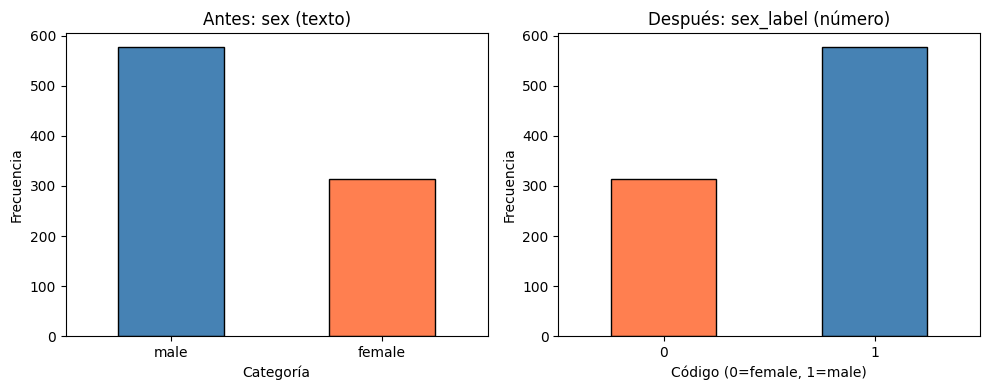

Las frecuencias son las mismas, solo cambia la representación.


In [9]:
# Gráfica de barras: sex antes y después de LabelEncoder
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# Antes: valores originales (male/female)
plt.subplot(1, 2, 1)
data['sex'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Antes: sex (texto)')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

# Después: valores codificados (0/1)
plt.subplot(1, 2, 2)
data['sex_label'].value_counts().sort_index().plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.title('Después: sex_label (número)')
plt.xlabel('Código (0=female, 1=male)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print('Las frecuencias son las mismas, solo cambia la representación.')

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [10]:
# OneHotEncoder para la columna 'class'
import pandas as pd

# Aplicar OneHotEncoder a 'class'
class_onehot = pd.get_dummies(data['class'], prefix='class')
print('Columnas creadas por OneHotEncoder:')
print(class_onehot.head(10))
print()

# Combinar con el dataset
data = pd.concat([data, class_onehot], axis=1)
print('Dataset con las nuevas columnas:')
print(data[['class', 'class_First', 'class_Second', 'class_Third']].head(10))
print()

print('Ventajas sobre LabelEncoder para class:')
print('1. LabelEncoder asignaría: First=0, Second=1, Third=2')
print('   El modelo pensaría que Third > Second > First (orden falso)')
print('2. OneHotEncoder crea columnas independientes (0 o 1)')
print('   No hay orden implícito, cada clase es igual')
print('3. Para una variable nominal (sin orden natural), OneHot es correcto')

Columnas creadas por OneHotEncoder:
   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True
5        False         False         True
6         True         False        False
7        False         False         True
8        False         False         True
9        False          True        False

Dataset con las nuevas columnas:
    class  class_First  class_Second  class_Third
0   Third        False         False         True
1   First         True         False        False
2   Third        False         False         True
3   First         True         False        False
4   Third        False         False         True
5   Third        False         False         True
6   First         True         False        False
7   Third        False         False         True
8   Third        F

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [11]:
# ¿Qué codificación elegir para modelos de aprendizaje automático?
print('Respuesta:')
print('Depende del tipo de variable categórica:')
print()
print('1. Variables con SOLO 2 categorías (binarias):')
print('   → LabelEncoder está bien (ej: male/female → 0/1)')
print()
print('2. Variables con 3+ categorías SIN orden (nominales):')
print('   → OneHotEncoder es mejor (ej: ciudades, clases de pasajero)')
print('   → Evita que el modelo "invente" un orden que no existe')
print()
print('3. Variables con 3+ categorías CON orden (ordinales):')
print('   → LabelEncoder puede funcionar (ej: bajo/medio/alto)')
print('   → Pero hay que asegurar que los números reflejen el orden real')
print()
print('En resumen: para la mayoría de modelos de ML,')
print('OneHotEncoder es la opción más segura para variables nominales.')

Respuesta:
Depende del tipo de variable categórica:

1. Variables con SOLO 2 categorías (binarias):
   → LabelEncoder está bien (ej: male/female → 0/1)

2. Variables con 3+ categorías SIN orden (nominales):
   → OneHotEncoder es mejor (ej: ciudades, clases de pasajero)
   → Evita que el modelo "invente" un orden que no existe

3. Variables con 3+ categorías CON orden (ordinales):
   → LabelEncoder puede funcionar (ej: bajo/medio/alto)
   → Pero hay que asegurar que los números reflejen el orden real

En resumen: para la mayoría de modelos de ML,
OneHotEncoder es la opción más segura para variables nominales.
